# 23CSE301 Machine Learning - Capstone Project
## Track 2: Classification Track - Part A (Review 1 Deliverable)
**Academic Year 2026-27 | B.Tech CSE III Year**

---
### Track Overview
This notebook presents **Part A of the Classification Track** for **Review 1**.
Per the capstone guidelines, Part A evaluates the first 5 core classification algorithms trained on the `adult.csv` (Adult / Census Income) dataset using stratified train/test splitting and standardized preprocessing. The task is to predict whether an individual's annual income exceeds $50K (`income` target: `<=50K` vs `>50K`).

#### Part A Algorithms:
1. Logistic Regression
2. K-Nearest Neighbors (KNN) Classifier
3. Naive Bayes (GaussianNB)
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

---


In [1]:
# ============================================================
# 23CSE301 Machine Learning - Classification Track
# Part A - Core Classification Algorithms
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Plot configuration
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

warnings.filterwarnings('ignore')

print("Classification libraries successfully imported!")

Classification libraries successfully imported!


## Section A - Dataset Loading & Exploratory Data Analysis (EDA)
### A1: Dataset Audit
We load `adult.csv` and audit its structure, missing values, and class balance.


In [2]:
# ============================================================
# A1: Dataset Loading & Audit
# ============================================================

df_raw = pd.read_csv('../data/adult.csv')

# Replace '?' with NaN
df_raw.replace('?', np.nan, inplace=True)

print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

print("\n--- Column Data Types ---")
print(df_raw.dtypes)

print("\n--- Missing Values ---")
print(df_raw.isnull().sum())

print("\n--- Target ('income') Class Distribution ---")
target_distribution = (
    df_raw['income']
    .value_counts(normalize=True)
    .rename_axis('income')
    .reset_index(name='proportion')
)

target_distribution['percentage'] = (
    target_distribution['proportion'] * 100
).round(2)

print(target_distribution[['income', 'percentage']].to_string(index=False))

Dataset Shape: 32561 rows, 15 columns

--- Column Data Types ---
age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

--- Missing Values ---
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

--- Target ('income') Class Distribution ---
income  percentage
 <=50K       75.92
  >50K       24.08


In [3]:
print(df_raw.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [4]:
target_col='income'

### A3 Insight Commentary: Dataset Audit
* **Target Balance**: `income` class balance is ~76% `<=50K` and ~24% `>50K`, indicating notable class imbalance suitable for Stratified K-Fold splitting.
* **Missing Values**: Missing values (encoded as `?` in the raw file) appear in `workclass` (~5.6%), `occupation` (~5.7%), and `native.country` (~1.8%), all of which are imputed using the column mode.


### A2: EDA Visualizations

The following visualizations examine the distributions of all features,
the target class distribution, correlations among numerical features,
and relationships between selected numerical features and the income
target.

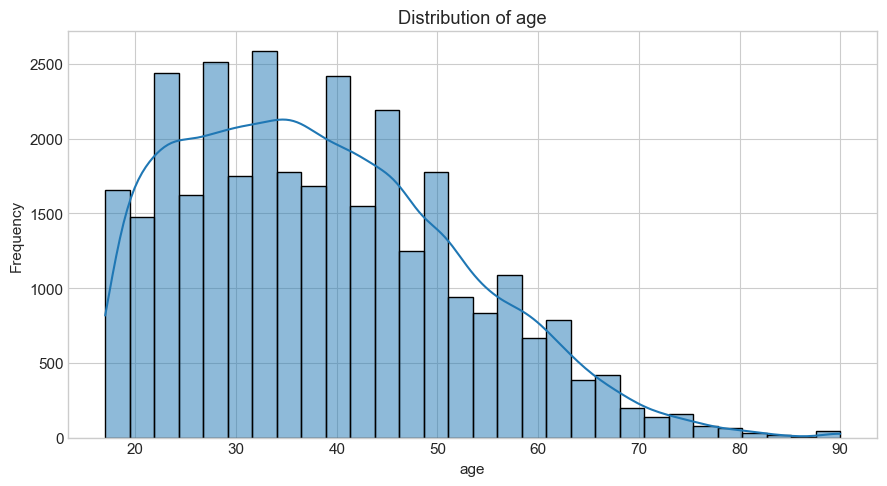

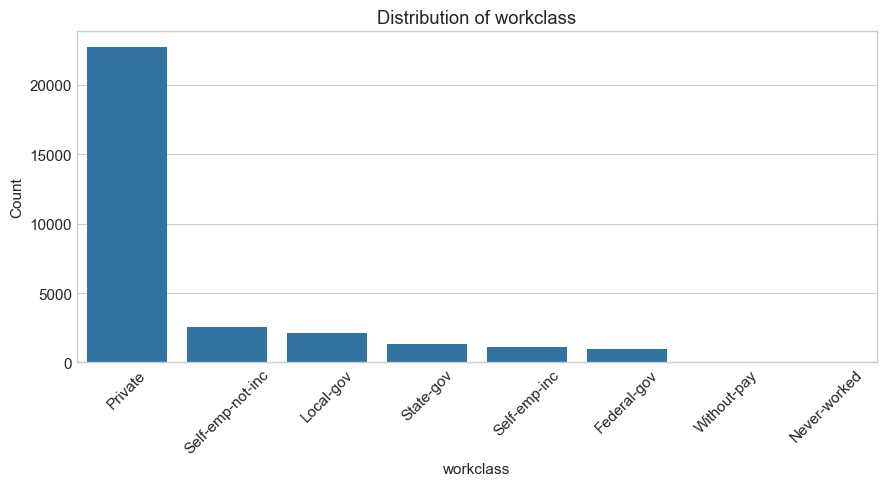

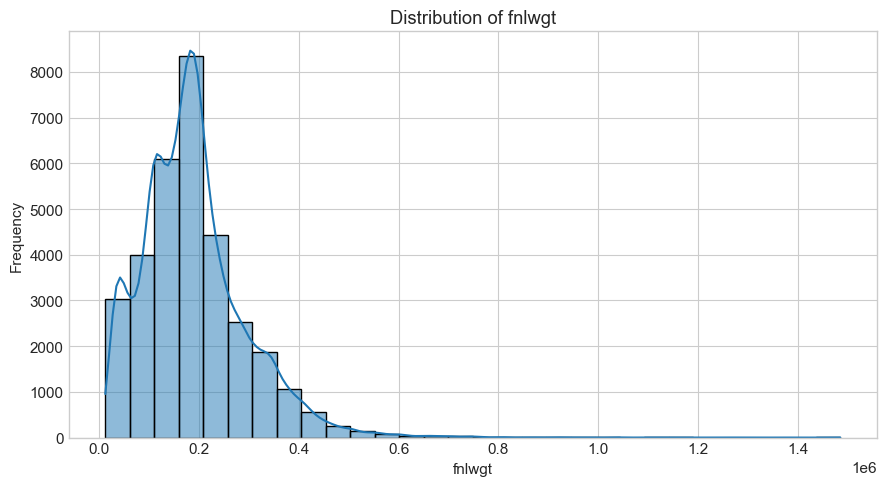

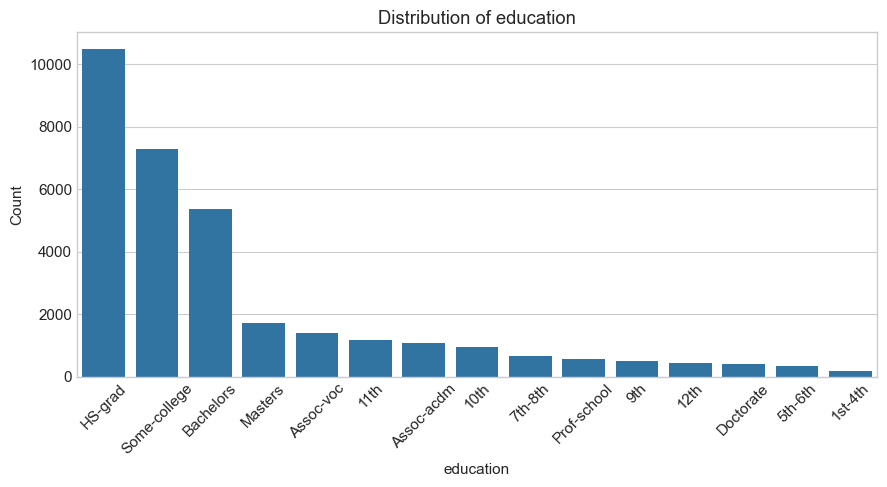

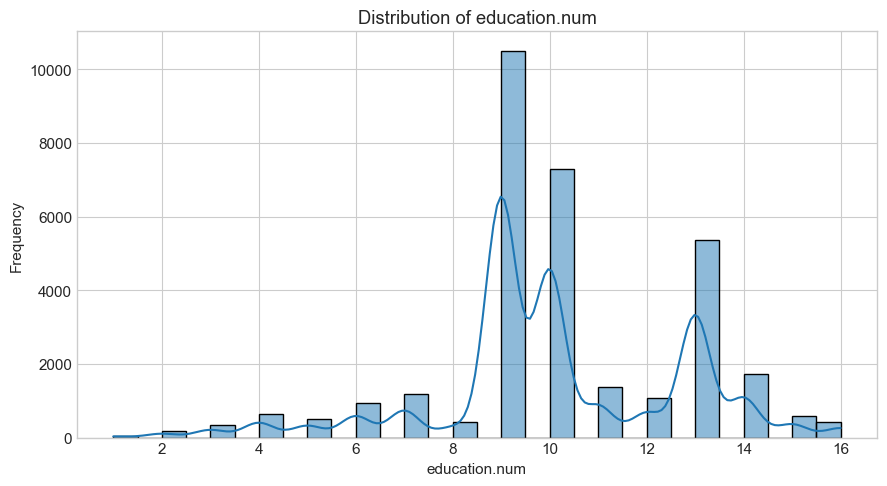

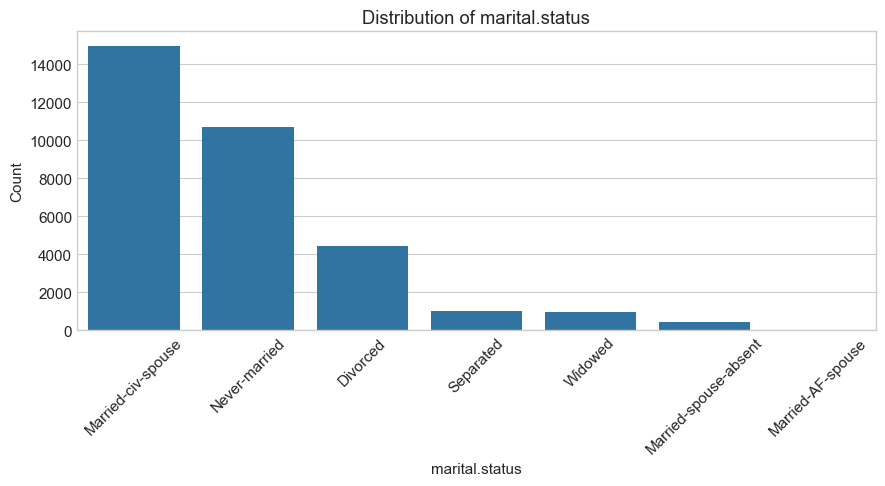

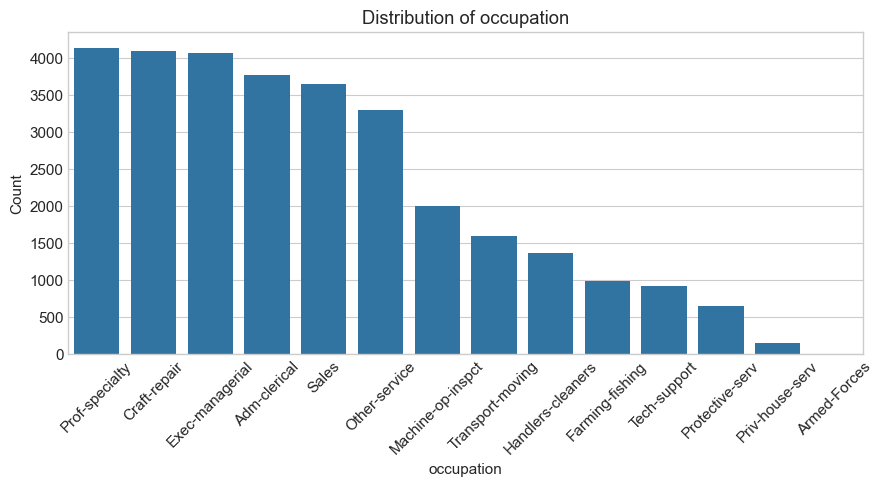

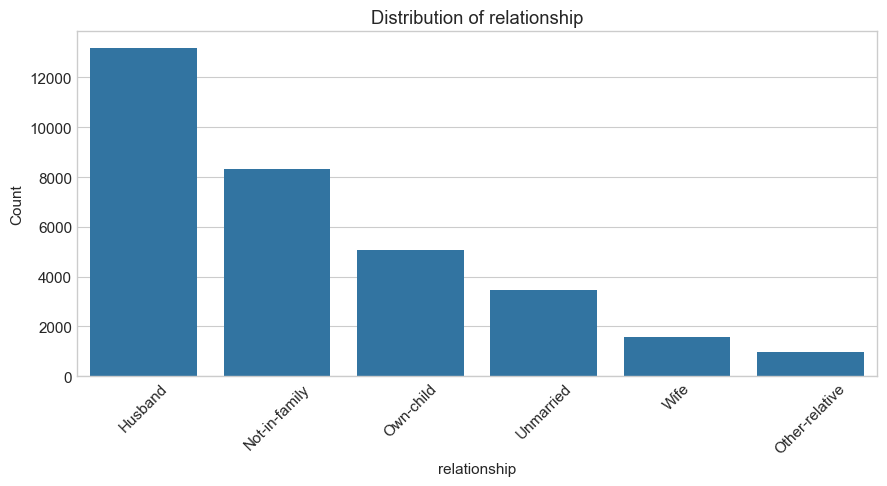

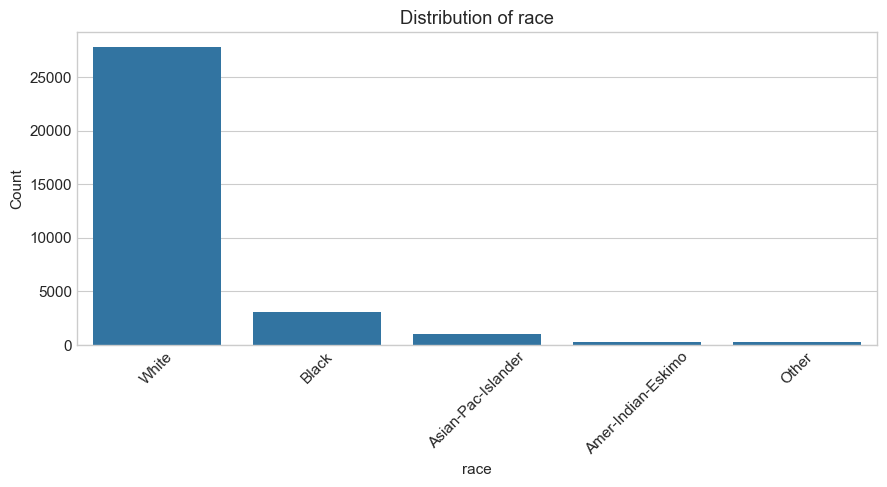

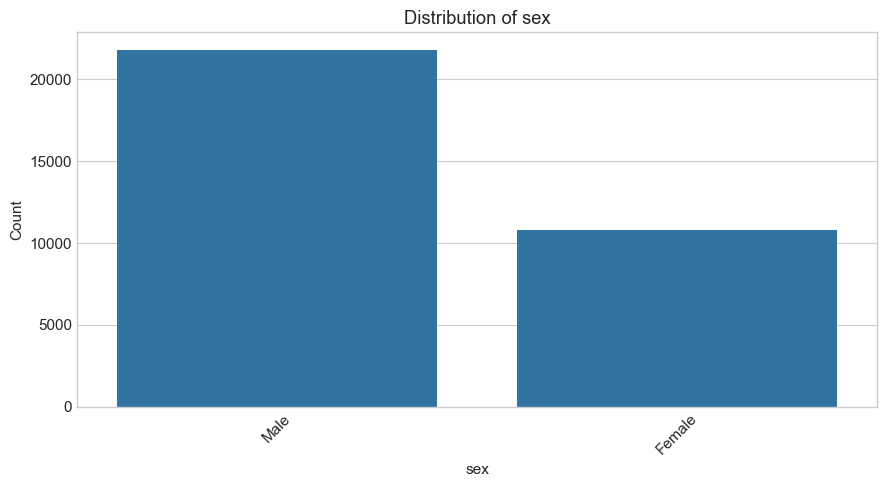

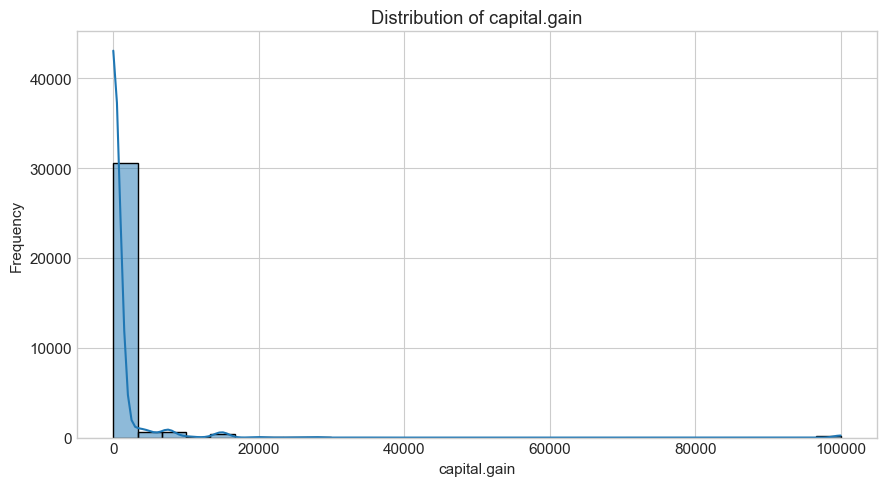

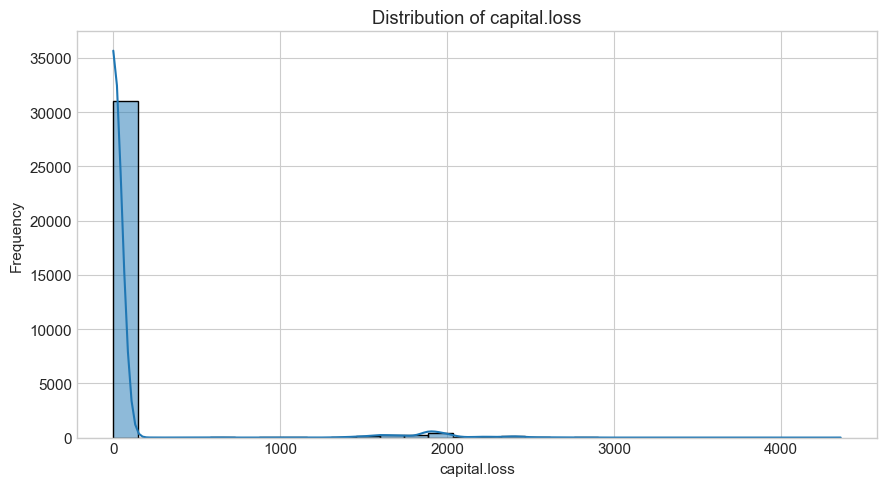

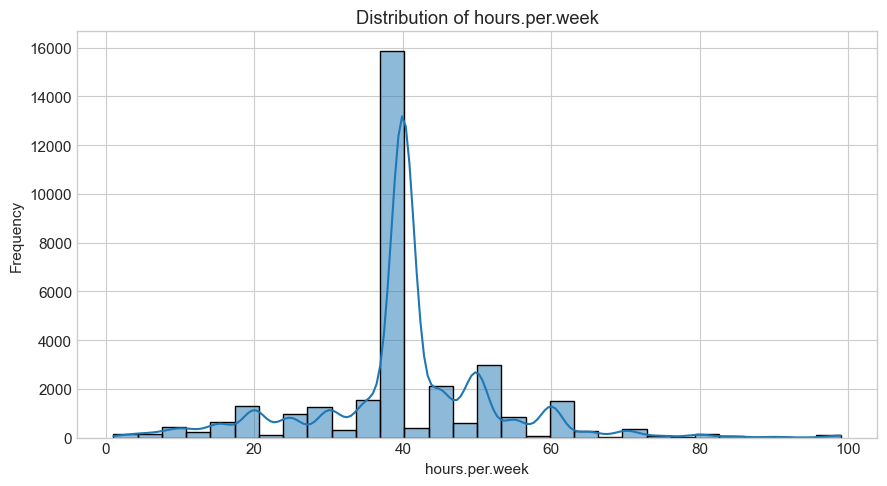

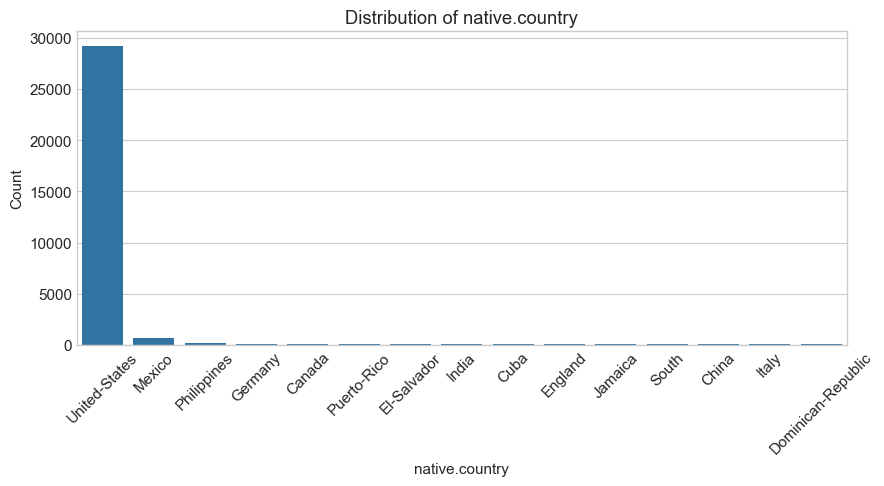

In [5]:
# ============================================================
# CLASSIFICATION — A2: DISTRIBUTION PLOTS FOR EVERY FEATURE
# ============================================================

features = [col for col in df_raw.columns if col != target_col]

for col in features:

    plt.figure(figsize=(9, 5))

    if pd.api.types.is_numeric_dtype(df_raw[col]):

        sns.histplot(
            df_raw[col].dropna(),
            kde=True,
            bins=30
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {col}")

    else:

        # Limit very high-cardinality categorical variables
        order = df_raw[col].value_counts().head(15).index

        sns.countplot(
            data=df_raw,
            x=col,
            order=order
        )

        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


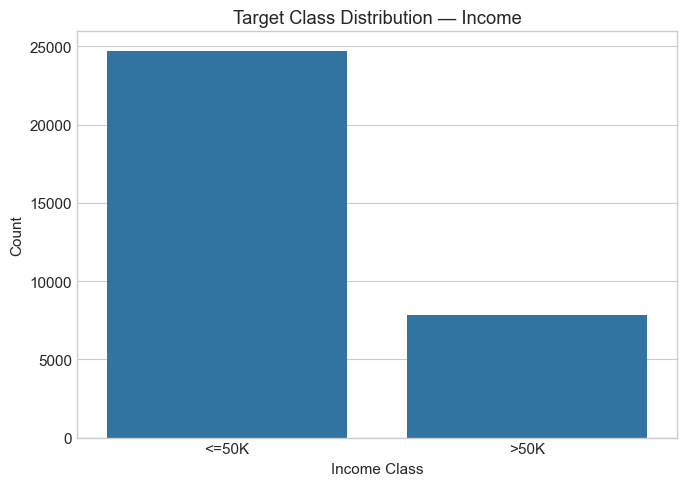

In [8]:
# ============================================================
# CLASSIFICATION — A2: TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_raw,
    x=target_col,
    order=df_raw[target_col].value_counts().index
)

plt.xlabel("Income Class")
plt.ylabel("Count")
plt.title("Target Class Distribution — Income")

plt.tight_layout()
plt.show()

In [10]:
print("Target Class Percentages:")

print(
    df_raw[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target Class Percentages:
income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


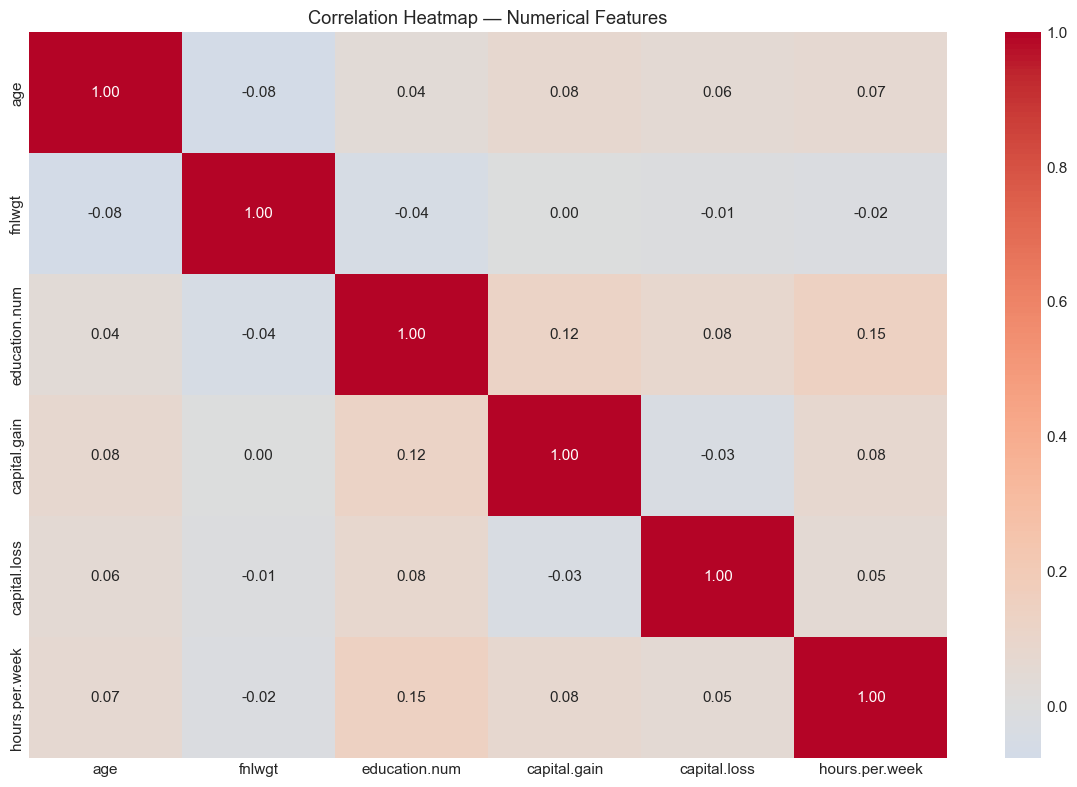

In [12]:
# ============================================================
# CLASSIFICATION — A2: CORRELATION HEATMAP
# ============================================================

numeric_df = df_raw.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — Numerical Features")

plt.tight_layout()
plt.show()

Selected features:
['education.num', 'age']


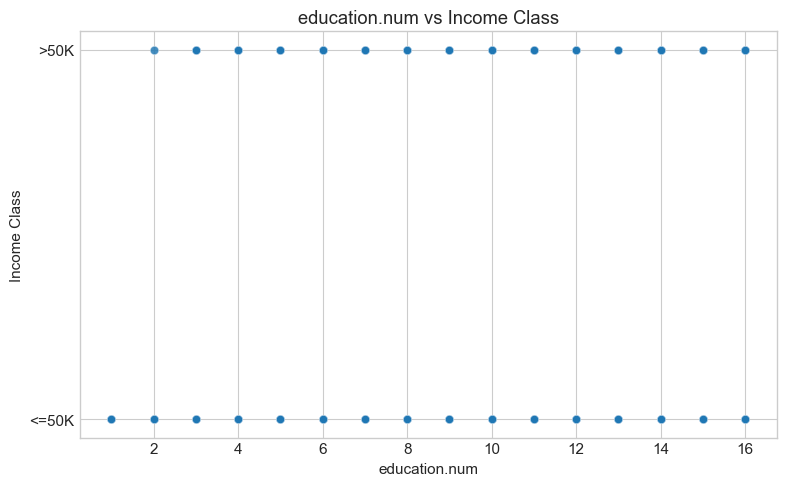

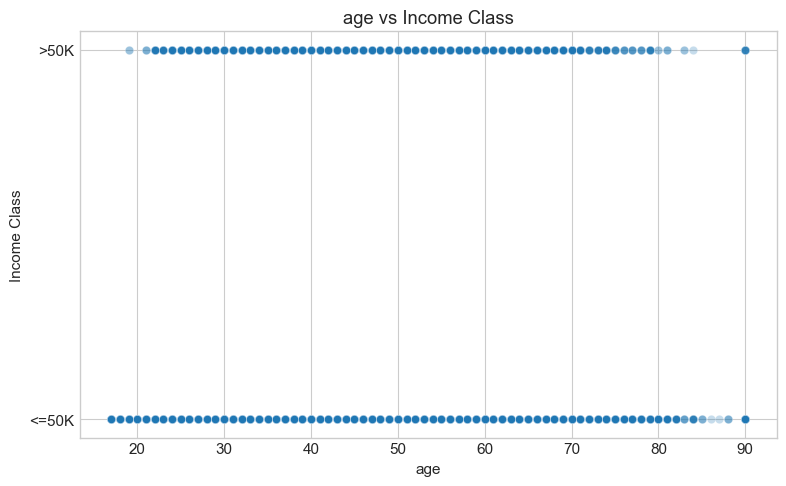

In [14]:
# ============================================================
# CLASSIFICATION — A2: FEATURE VS TARGET RELATIONSHIPS
# ============================================================

# Temporary numerical representation ONLY for EDA visualization
target_numeric = (
    df_raw[target_col]
    .astype(str)
    .str.contains(">50K")
    .astype(int)
)

numeric_features = df_raw.select_dtypes(include=np.number).columns.tolist()

# Remove target if it happens to be numeric
numeric_features = [
    col for col in numeric_features
    if col != target_col
]

# Select two numerical features with strongest correlation
# to the temporary binary target
feature_correlations = (
    df_raw[numeric_features]
    .corrwith(target_numeric)
    .abs()
    .sort_values(ascending=False)
)

top_two_features = feature_correlations.head(2).index.tolist()

print("Selected features:")
print(top_two_features)

for feature in top_two_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        x=df_raw[feature],
        y=target_numeric,
        alpha=0.25
    )

    plt.yticks(
        [0, 1],
        ["<=50K", ">50K"]
    )

    plt.xlabel(feature)
    plt.ylabel("Income Class")
    plt.title(f"{feature} vs Income Class")

    plt.tight_layout()
    plt.show()

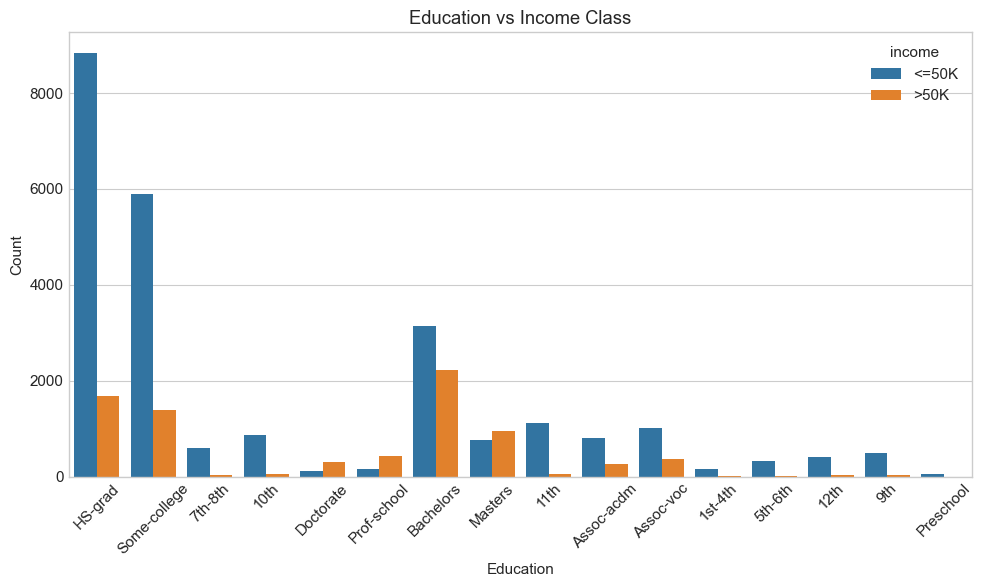

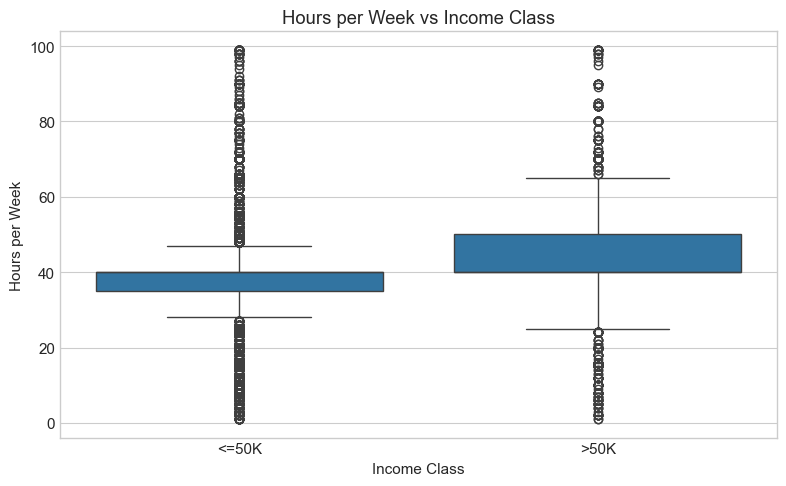

In [15]:
# ============================================================
# CLASSIFICATION — ADDITIONAL FEATURE-TARGET RELATIONSHIPS
# ============================================================

# Education vs Income
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_raw,
    x="education",
    hue=target_col
)

plt.xticks(rotation=45)
plt.xlabel("Education")
plt.ylabel("Count")
plt.title("Education vs Income Class")

plt.tight_layout()
plt.show()


# Hours-per-week vs Income
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_raw,
    x=target_col,
    y="hours.per.week"
)

plt.xlabel("Income Class")
plt.ylabel("Hours per Week")
plt.title("Hours per Week vs Income Class")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CLASSIFICATION — A3: EDA OBSERVATIONS
# ============================================================

print("""
EDA Observations:

1. The target distribution shows that the income classes are
   imbalanced, with <=50K representing the majority class.

2. The feature distribution plots show substantial variation
   among demographic, employment and financial attributes.

3. The correlation heatmap shows the relationships among the
   numerical features, with some features exhibiting stronger
   associations than others.

4. Education level shows a relationship with income class, with
   higher education levels generally associated with a larger
   proportion of the >50K class.

5. The hours-per-week visualization shows differences in working
   hours between the income classes.

6. The feature-target visualizations provide preliminary evidence
   that some features may be useful for predicting income class.
""")


EDA Observations:

1. The target distribution shows that the income classes are
   imbalanced, with <=50K representing the majority class.

2. The feature distribution plots show substantial variation
   among demographic, employment and financial attributes.

3. The correlation heatmap shows the relationships among the
   numerical features, with some features exhibiting stronger
   associations than others.

4. Education level shows a relationship with income class, with
   higher education levels generally associated with a larger
   proportion of the >50K class.

5. The hours-per-week visualization shows differences in working
   hours between the income classes.

6. The feature-target visualizations provide preliminary evidence
   that some features may be useful for predicting income class.



### A3 Insight Commentary: EDA Visualizations
* **Education**: Individuals with `Bachelors`, `Masters`, or `Doctorate` degrees show a markedly higher proportion earning `>50K` compared to `HS-grad` or lower education levels.
* **Working Hours**: Individuals earning `>50K` tend to work more hours per week on median than those earning `<=50K`.


In [18]:
# ============================================================
# B1: DATA CLEANING — MISSING VALUES, DUPLICATES & OUTLIERS
# ============================================================

# ------------------------------------------------------------
# 1. Missing-value analysis
# ------------------------------------------------------------

print("Missing Values Before Treatment:")
missing_before = df_raw.isnull().sum()
print(missing_before[missing_before > 0])

print("\nTotal Missing Values:", df_raw.isnull().sum().sum())


# ------------------------------------------------------------
# 2. Duplicate-row check
# ------------------------------------------------------------

duplicate_count = df_raw.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

if duplicate_count > 0:
    print("Duplicate rows detected and removed.")
    df_raw = df_raw.drop_duplicates().reset_index(drop=True)
else:
    print("No duplicate rows detected.")


# ------------------------------------------------------------
# 3. Missing-value treatment
# ------------------------------------------------------------

# Identify numerical and categorical columns
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude=np.number).columns.tolist()

# Do not impute the target variable
if target_col in categorical_cols:
    categorical_features = [
        col for col in categorical_cols
        if col != target_col
    ]
else:
    categorical_features = categorical_cols

# Numerical columns → median imputation
for col in numeric_cols:
    if df_raw[col].isnull().sum() > 0:
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

# Categorical columns → mode imputation
for col in categorical_features:
    if df_raw[col].isnull().sum() > 0:
        df_raw[col] = df_raw[col].fillna(df_raw[col].mode()[0])

print("\nMissing Values After Treatment:")
print(df_raw.isnull().sum().sum())


# ------------------------------------------------------------
# 4. Outlier detection using IQR
# ------------------------------------------------------------

print("\nOutlier Analysis (IQR Method):")

outlier_summary = []

for col in numeric_cols:

    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_raw[col] < lower_bound) |
        (df_raw[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)


# ------------------------------------------------------------
# 5. Outlier treatment
# ------------------------------------------------------------

# Keep the original observations but cap extreme numerical
# values at their IQR boundaries (winsorization).

for col in numeric_cols:

    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_raw[col] = df_raw[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("\nOutlier treatment completed using IQR-based capping.")

print("\nFinal Dataset Shape:", df_raw.shape)

Missing Values Before Treatment:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Total Missing Values: 4262

Duplicate Rows: 24
Duplicate rows detected and removed.

Missing Values After Treatment:
0

Outlier Analysis (IQR Method):


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,age,28.0,48.0,20.0,-2.0,78.0,142
1,fnlwgt,117827.0,236993.0,119166.0,-60922.0,415742.0,993
2,education.num,9.0,12.0,3.0,4.5,16.5,1193
3,capital.gain,0.0,0.0,0.0,0.0,0.0,2712
4,capital.loss,0.0,0.0,0.0,0.0,0.0,1519
5,hours.per.week,40.0,45.0,5.0,32.5,52.5,9002



Outlier treatment completed using IQR-based capping.

Final Dataset Shape: (32537, 15)


### B1: Missing Values, Duplicates and Outliers

Missing values were first identified and treated using median
imputation for numerical features and mode imputation for categorical
features. Duplicate rows were checked and removed when present.

Numerical features were examined for potential outliers using the
Interquartile Range (IQR) method. Extreme values beyond 1.5 × IQR
from the first and third quartiles were identified. Instead of
removing observations, IQR-based capping was applied to limit the
influence of extreme values while preserving the available samples.

## Section B - Preprocessing & Feature Engineering
### B1 & B2: Data Imputation, Encoding, Scaling & Stratified Split
We impute missing `workclass`, `occupation`, and `native.country` values with their mode, engineer `Capital_Net` and `Has_Capital_Gain` features, one-hot encode categorical features, scale numerical features strictly on `X_train`, and perform an 80:20 stratified split (`random_state=42`).


In [20]:
# ============================================================
# B1-B3: Preprocessing & Feature Engineering
# ============================================================

df_clean = df_raw.copy()

# ------------------------------------------------------------
# 1. Handle missing categorical values
# ------------------------------------------------------------

categorical_missing_cols = [
    'workclass',
    'occupation',
    'native.country'
]

for col in categorical_missing_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

# ------------------------------------------------------------
# 2. Feature Engineering
# ------------------------------------------------------------

# Net capital = capital gain - capital loss
df_clean['Capital_Net'] = (
    df_clean['capital.gain'] -
    df_clean['capital.loss']
)

# Binary indicator for whether the person has capital gain
df_clean['Has_Capital_Gain'] = (
    df_clean['capital.gain'] > 0
).astype(int)

# ------------------------------------------------------------
# 3. Encode target
# <=50K -> 0
# >50K  -> 1
# ------------------------------------------------------------

df_clean['income'] = (
    df_clean['income'] == '>50K'
).astype(int)

# ------------------------------------------------------------
# 4. Separate features and target
# ------------------------------------------------------------

X = df_clean.drop(columns=['income'])
y = df_clean['income']

# Categorical features
cat_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

# Numerical features
num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

print("Number of numerical features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

# ------------------------------------------------------------
# 5. Stratified 80:20 Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

# ------------------------------------------------------------
# 6. Preprocessing Pipeline
# ------------------------------------------------------------

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

# Fit ONLY on training data
X_train_prep = preprocessor.fit_transform(X_train)

# Transform test data using fitted preprocessing
X_test_prep = preprocessor.transform(X_test)

# Feature names after preprocessing
encoded_cat_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
)

feature_names = (
    num_cols +
    list(encoded_cat_names)
)

print("\nPreprocessed X_train shape:", X_train_prep.shape)
print("Preprocessed X_test shape:", X_test_prep.shape)
print("Total features after encoding:", len(feature_names))

Number of numerical features: 8
Number of categorical features: 8

Train samples: 26029
Test samples: 6508

Training class distribution:
income
0    0.759076
1    0.240924
Name: proportion, dtype: float64

Testing class distribution:
income
0    0.759066
1    0.240934
Name: proportion, dtype: float64

Preprocessed X_train shape: (26029, 98)
Preprocessed X_test shape: (6508, 98)
Total features after encoding: 98


## Section D - Classification Track, Part A (5 Algorithms)
We implement all 5 Part A classification algorithms, record predictions, and compile standard evaluation metrics (Accuracy, Precision, Recall, Weighted F1, Confusion Matrix, and ROC-AUC).


In [21]:
# ============================================================
# D: Classification Track - Part A
# Five Core Classification Algorithms
# ============================================================

models_clf = {

    "1. Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "2. K-Nearest Neighbors (k=7)":
        KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            n_jobs=-1
        ),

    "3. Naive Bayes (GaussianNB)":
        GaussianNB(),

    "4. Decision Tree Classifier (max_depth=4)":
        DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ),

    "5. Support Vector Classifier (SVC)":
        SVC(
            kernel='rbf',
            C=1.0,
            probability=False,
            random_state=42
        )
}

pred_dict = {}
prob_dict = {}
results = []

for name, model in models_clf.items():

    print(f"Training: {name}")

    model.fit(X_train_prep, y_train)

    y_pred = model.predict(X_test_prep)

    pred_dict[name] = y_pred

    # Probability for models that support it;
    # decision score for SVC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_prep)[:, 1]
    else:
        y_score = model.decision_function(X_test_prep)

    prob_dict[name] = y_score

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(
            y_test, y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_score
        )
    })

    print("  Completed.")

df_results_clf = pd.DataFrame(results)

df_results_clf = (
    df_results_clf
    .sort_values(
        by="F1_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

df_results = df_results_clf.copy()

print("\n" + "=" * 80)
print("CLASSIFICATION PART A - PRELIMINARY COMPARISON TABLE")
print("=" * 80)

print(
    df_results_clf.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nBest model:")
print(df_results_clf.iloc[0]["Algorithm"])

Training: 1. Logistic Regression
  Completed.
Training: 2. K-Nearest Neighbors (k=7)
  Completed.
Training: 3. Naive Bayes (GaussianNB)
  Completed.
Training: 4. Decision Tree Classifier (max_depth=4)
  Completed.
Training: 5. Support Vector Classifier (SVC)
  Completed.

CLASSIFICATION PART A - PRELIMINARY COMPARISON TABLE
                                Algorithm  Accuracy  Precision  Recall  F1_Score  ROC_AUC
       5. Support Vector Classifier (SVC)    0.8360     0.8273  0.8360    0.8284   0.8673
                   1. Logistic Regression    0.8348     0.8265  0.8348    0.8281   0.8832
             2. K-Nearest Neighbors (k=7)    0.8115     0.8097  0.8115    0.8106   0.8486
4. Decision Tree Classifier (max_depth=4)    0.8213     0.8111  0.8213    0.8003   0.8620
              3. Naive Bayes (GaussianNB)    0.5045     0.8017  0.5045    0.5159   0.7010

Best model:
5. Support Vector Classifier (SVC)


### Model Interpretations & Theoretical Analysis
1. **Logistic Regression Coefficients**:
   * Features with positive log-odds coefficients increase the predicted probability of earning `>50K` (e.g. `education.num`, `hours.per.week`, `marital.status_Married-civ-spouse`).
2. **Naive Bayes Conditional Independence Assumption**:
   * GaussianNB assumes features are conditionally independent given the class. This is violated for correlated features (e.g. `education` & `education.num`), but GaussianNB remains a fast, interpretable baseline.
3. **KNN Distance Metrics**:
   * Euclidean distance is applied after `StandardScaler` normalization to ensure equal feature weighting across numerical attributes like `age`, `hours.per.week`, and `capital.gain`.
4. **Decision Tree Depth**:
   * Tree depth constrained to `max_depth=4` to prevent overfitting and enable clear visualization of the most influential income-determining splits.


### Visualizations: Confusion Matrices, Overlayed ROC Curves & Decision Tree
Below we plot confusion matrices for all 5 Part A models, overlayed ROC curves, and the Decision Tree diagram.


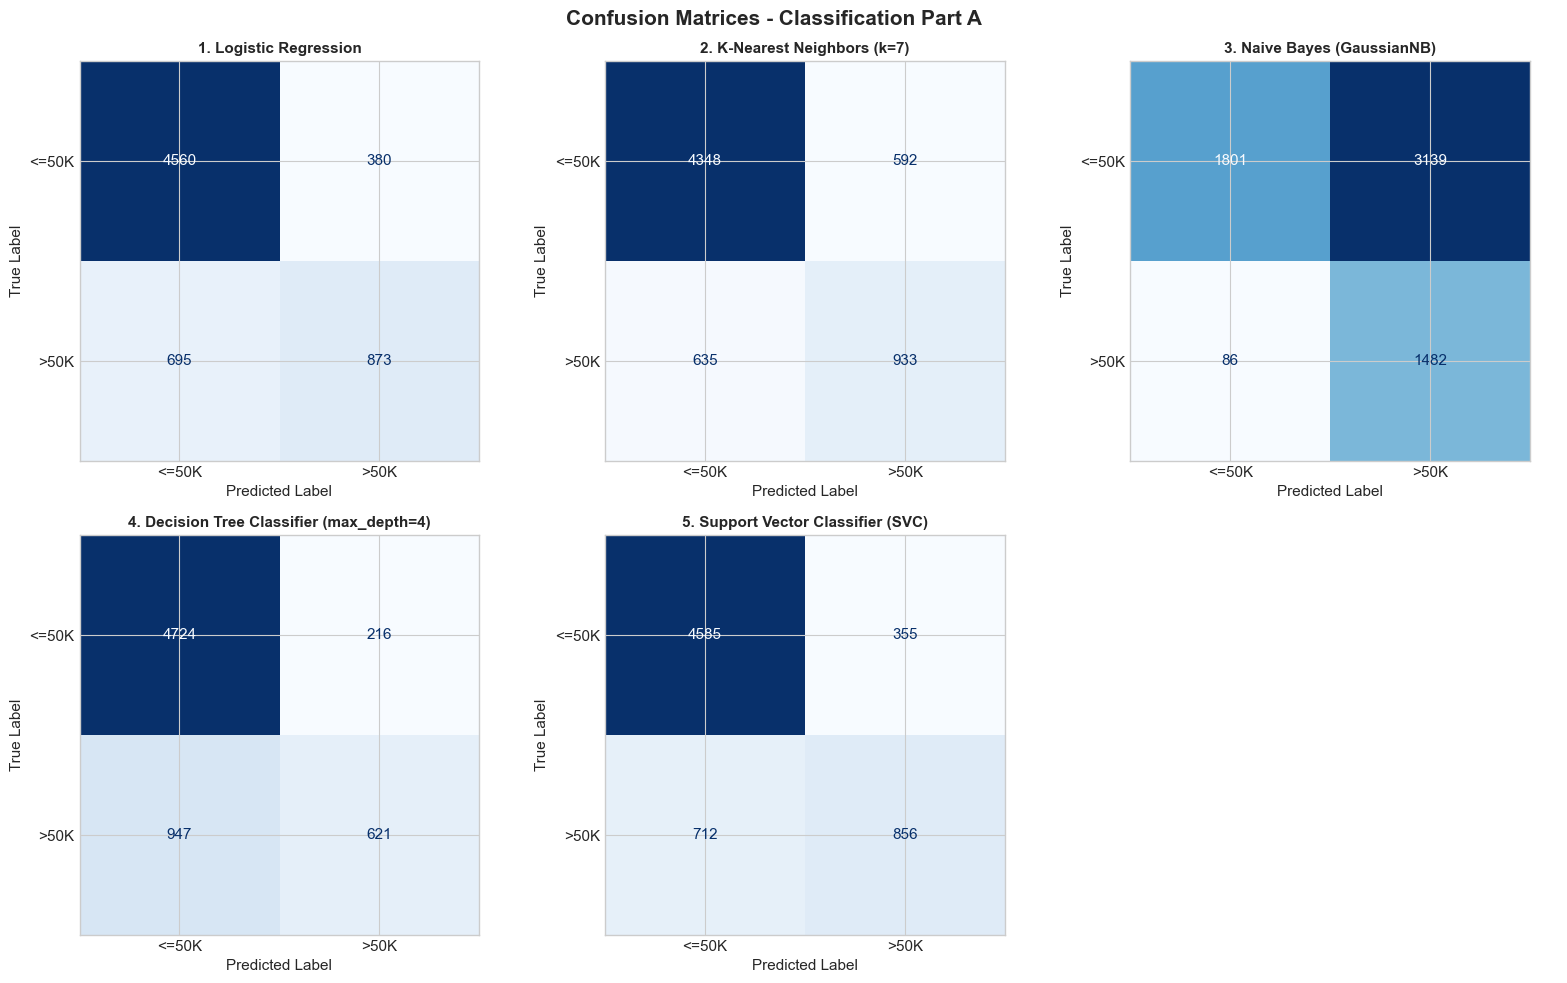

In [22]:
# ============================================================
# Confusion Matrices - All Part A Models
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.flatten()

for idx, (name, model) in enumerate(models_clf.items()):

    cm = confusion_matrix(
        y_test,
        pred_dict[name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['<=50K', '>50K']
    )

    disp.plot(
        ax=axes[idx],
        cmap='Blues',
        colorbar=False
    )

    axes[idx].set_title(
        name,
        fontsize=11,
        fontweight='bold'
    )

    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Hide unused subplot
axes[5].axis('off')

plt.suptitle(
    'Confusion Matrices - Classification Part A',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

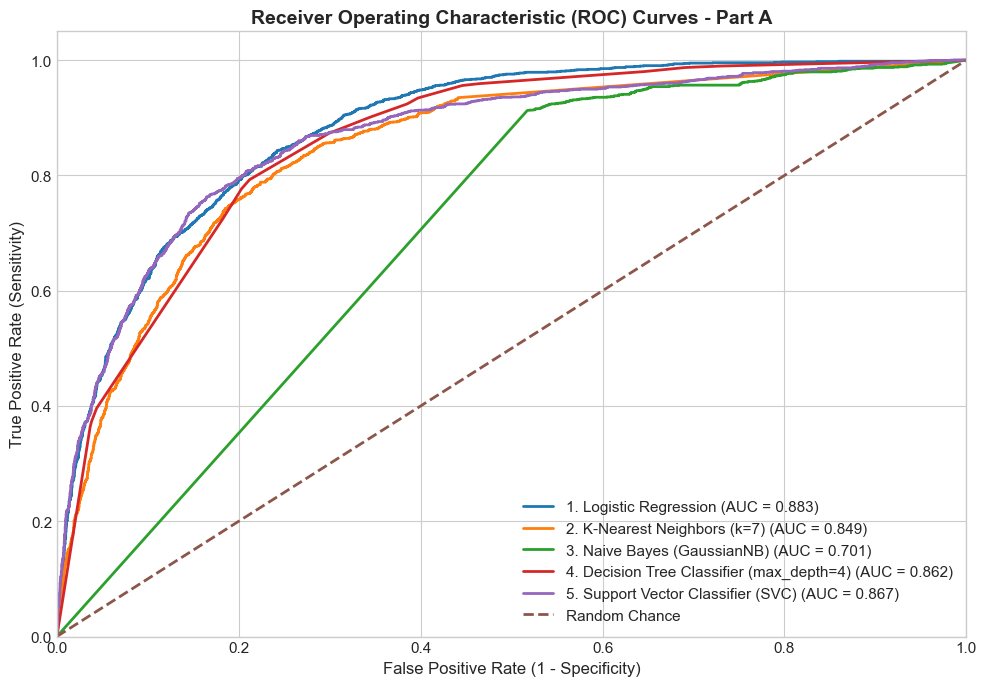

In [23]:
# ============================================================
# ROC Curves - All Part A Models
# ============================================================

plt.figure(figsize=(10, 7))

for name, y_score in prob_dict.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC = {roc_auc_value:.3f})'
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    lw=2,
    label='Random Chance'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    'False Positive Rate (1 - Specificity)',
    fontsize=12
)

plt.ylabel(
    'True Positive Rate (Sensitivity)',
    fontsize=12
)

plt.title(
    'Receiver Operating Characteristic (ROC) Curves - Part A',
    fontsize=14,
    fontweight='bold'
)

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

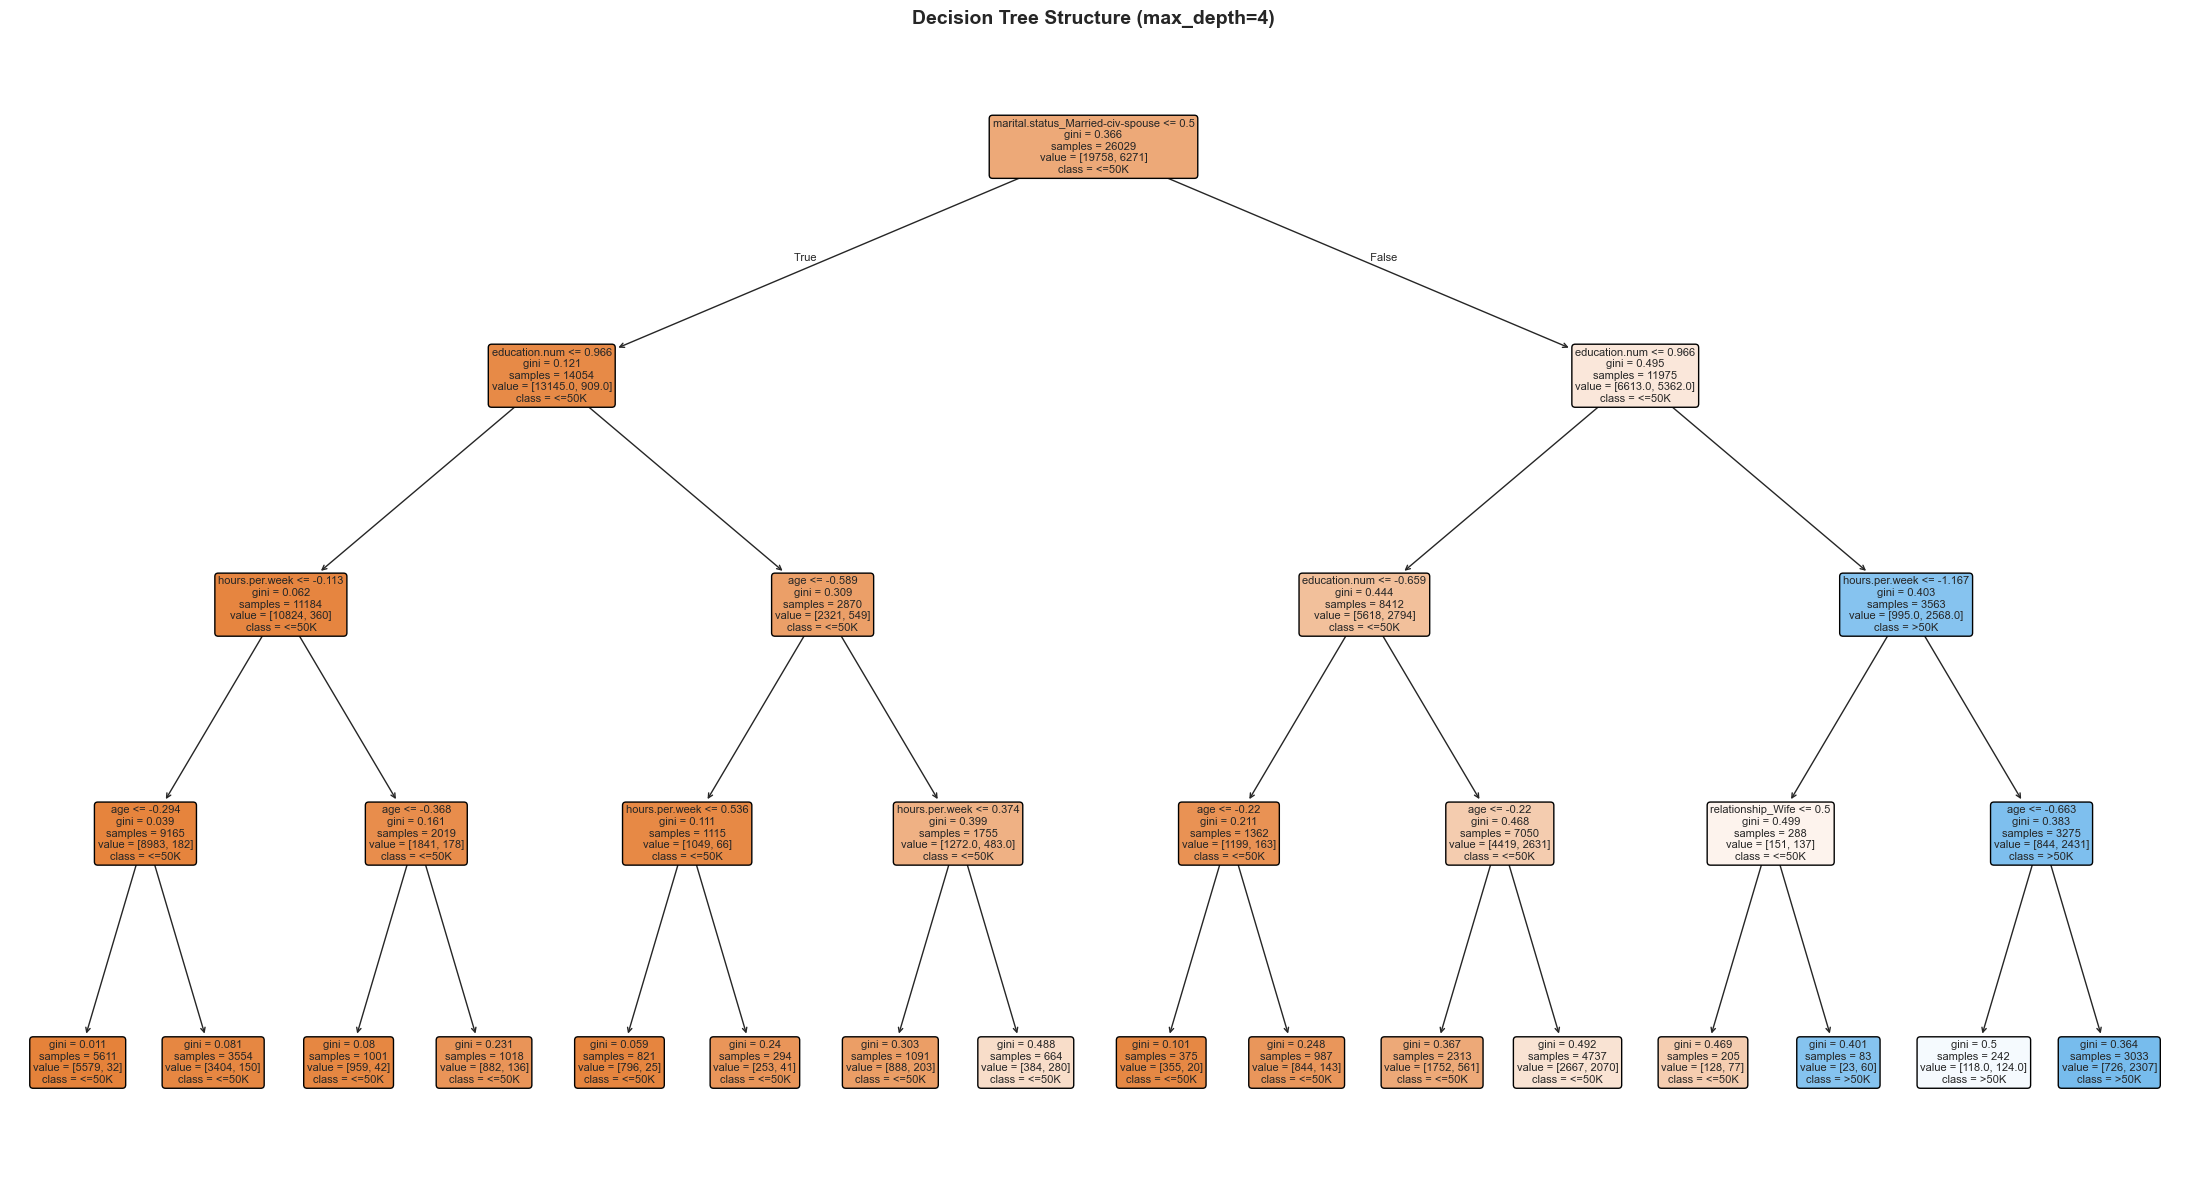

In [24]:
# ============================================================
# Decision Tree Visualization
# ============================================================

dt_model = models_clf[
    "4. Decision Tree Classifier (max_depth=4)"
]

plt.figure(
    figsize=(22, 12)
)

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    'Decision Tree Structure (max_depth=4)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

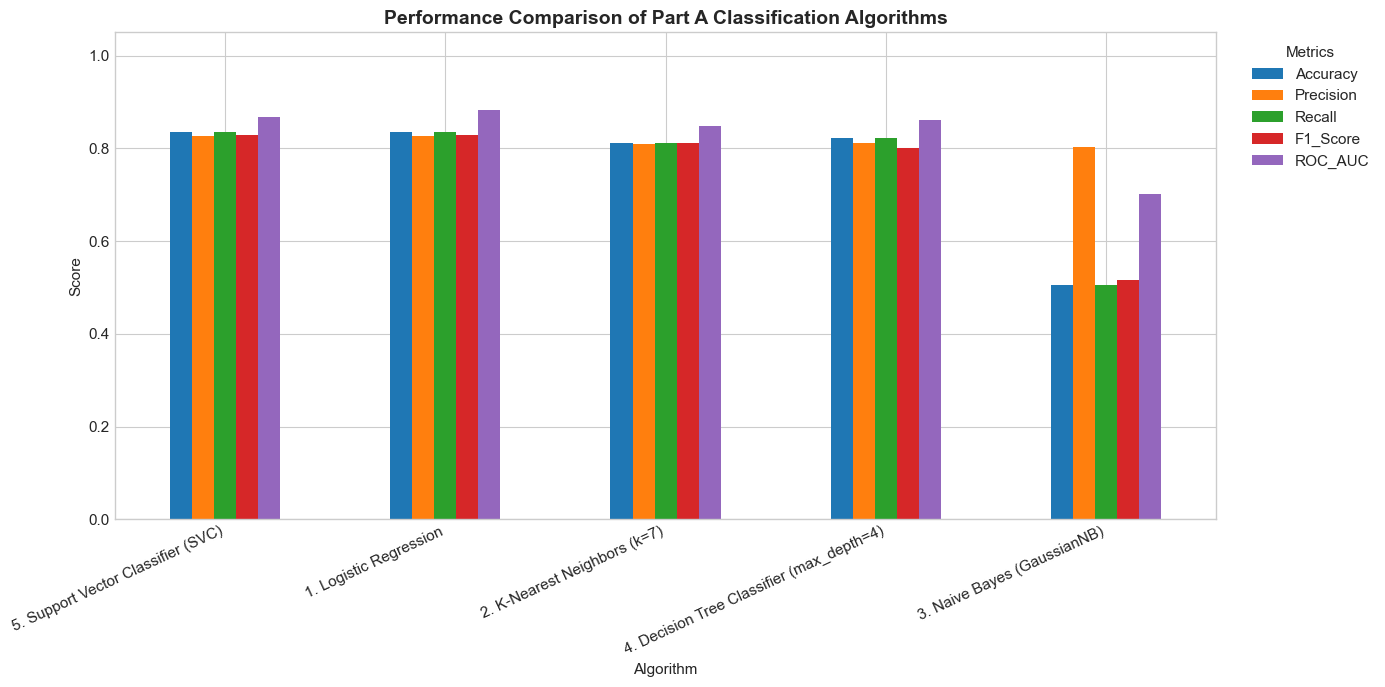

In [25]:
# ============================================================
# Model Performance Comparison
# ============================================================

metrics_to_plot = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1_Score',
    'ROC_AUC'
]

plot_df = df_results_clf.set_index(
    'Algorithm'
)[metrics_to_plot]

ax = plot_df.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title(
    'Performance Comparison of Part A Classification Algorithms',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Algorithm')
plt.ylabel('Score')

plt.ylim(0, 1.05)

plt.xticks(
    rotation=25,
    ha='right'
)

plt.legend(
    title='Metrics',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Save Best Part A Model
# ============================================================

best_clf_name = df_results_clf.iloc[0]['Algorithm']

best_clf_model = models_clf[
    best_clf_name
]

os.makedirs(
    '../models',
    exist_ok=True
)

model_path = '../models/classification_best_model.pkl'

joblib.dump(
    {
        'model': best_clf_model,
        'preprocessor': preprocessor,
        'feature_names': feature_names,
        'algorithm': best_clf_name
    },
    model_path
)

print("=" * 70)
print("BEST PART A MODEL")
print("=" * 70)

print(f"Algorithm : {best_clf_name}")
print(
    f"Weighted F1 : "
    f"{df_results_clf.iloc[0]['F1_Score']:.4f}"
)

print(f"\nModel saved successfully to:")
print(model_path)

BEST PART A MODEL
Algorithm : 5. Support Vector Classifier (SVC)
Weighted F1 : 0.8284

Model saved successfully to:
models/classification_best_model.pkl


In [27]:
# ============================================================
# Detailed Evaluation of the Best Model
# ============================================================

from sklearn.metrics import classification_report

best_predictions = pred_dict[
    best_clf_name
]

print("=" * 70)
print(f"DETAILED CLASSIFICATION REPORT")
print(f"Best Model: {best_clf_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=['<=50K', '>50K'],
        digits=4,
        zero_division=0
    )
)

DETAILED CLASSIFICATION REPORT
Best Model: 5. Support Vector Classifier (SVC)
              precision    recall  f1-score   support

       <=50K     0.8656    0.9281    0.8958      4940
        >50K     0.7069    0.5459    0.6160      1568

    accuracy                         0.8360      6508
   macro avg     0.7862    0.7370    0.7559      6508
weighted avg     0.8273    0.8360    0.8284      6508



### Part A Summary & Transition to Review 2

The five required Part A classification algorithms were trained and evaluated on the Adult Income dataset using the same stratified 80:20 train/test split and preprocessing pipeline.

The models were compared using Accuracy, Weighted Precision, Weighted Recall, Weighted F1-score, and ROC-AUC.

The best-performing Part A model is identified automatically based on the highest Weighted F1-score in the comparison table above. This avoids selecting a model based on assumptions about expected performance.

### Key Observations

* Logistic Regression provides a strong linear baseline for the binary income classification problem.
* K-Nearest Neighbors performs classification using distances between standardized feature representations.
* Gaussian Naive Bayes provides a computationally efficient probabilistic baseline based on conditional independence assumptions.
* The Decision Tree provides an interpretable non-linear classifier while restricting `max_depth=4` to control model complexity.
* SVC with an RBF kernel captures non-linear decision boundaries and provides probability estimates for ROC-AUC analysis.

### Review 2 Scope

Review 2 will extend the classification study with the Part B algorithms specified in the capstone requirements and compare their performance against the five Part A models.